In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# BATCH NORMALIZATION NEDİR?
# ══════════════════════════════════════════════════════
#
# Problem: Derin ağlarda eğitim çok yavaş ve zor
#   Her katmandan geçince değerler büyür veya küçülür
#   Gradient ya patlar (çok büyür) ya da yok olur (sıfıra yaklaşır)
#
# Çözüm: Batch Normalization
#   Her katmandan sonra değerleri normalize et
#   Ortalama = 0, Standart sapma = 1 yap
#   Böylece değerler kontrol altında kalır
#
# Sonuç:
#   Daha hızlı eğitim
#   Daha yüksek learning rate kullanabilirsin
#   Ağ daha kararlı öğrenir
# ══════════════════════════════════════════════════════

print("Assignment 2 başlıyor!")

Assignment 2 başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Başlangıç → ortalama: -0.045, std: 0.987
10 katman sonra → ortalama: 0.002, std: 0.062


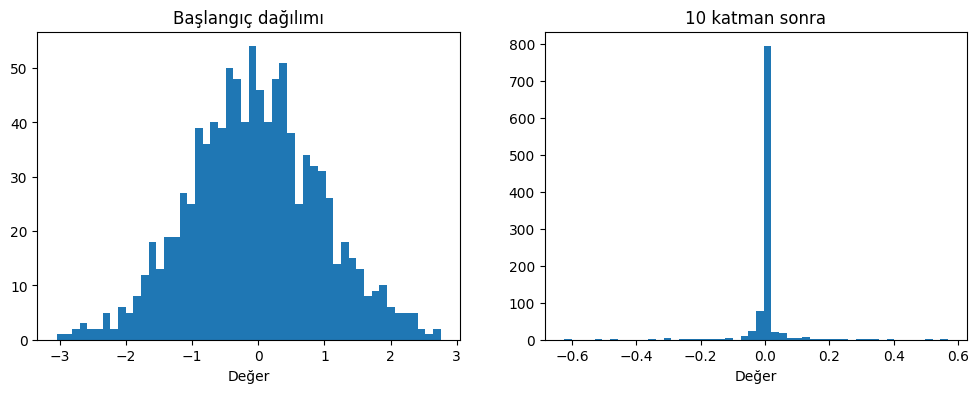


Sorun: Değerler -1 ve 1'e yapıştı!
Gradient burda sıfıra yaklaşır → ağ öğrenemez!


In [3]:
# ══════════════════════════════════════════════════════
# PROBLEM — DERİN AĞLARDA DEĞERLER NEDEN KAYAR?
# ══════════════════════════════════════════════════════
#
# Assignment 1'de 3 katmanlı ağ yaptık.
# Peki 10, 20, 50 katman olsaydı ne olurdu?
#
# Her katmandan geçince değerler büyür veya küçülür.
# Bunu simüle edelim:
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Başlangıç verisi
x = np.random.randn(1000)  # 1000 sayı, ortalama=0, std=1
print(f"Başlangıç → ortalama: {x.mean():.3f}, std: {x.std():.3f}")

# 10 katmandan geç (her katman W@x işlemi)
for i in range(10):
    W = np.random.randn(*x.shape) * 1.0  # rastgele ağırlık
    x = np.tanh(W * x)                   # aktivasyon

print(f"10 katman sonra → ortalama: {x.mean():.3f}, std: {x.std():.3f}")

# Görselleştir
plt.figure(figsize=(12, 4))

np.random.seed(0)
x = np.random.randn(1000)

plt.subplot(1, 2, 1)
plt.hist(x, bins=50)
plt.title("Başlangıç dağılımı")
plt.xlabel("Değer")

for i in range(10):
    W = np.random.randn(*x.shape) * 1.0
    x = np.tanh(W * x)

plt.subplot(1, 2, 2)
plt.hist(x, bins=50)
plt.title("10 katman sonra")
plt.xlabel("Değer")
plt.show()

print("\nSorun: Değerler -1 ve 1'e yapıştı!")
print("Gradient burda sıfıra yaklaşır → ağ öğrenemez!")

In [5]:
# ══════════════════════════════════════════════════════
# BATCH NORMALIZATION — ÇÖZÜM
# ══════════════════════════════════════════════════════
#
# Her katmandan sonra şunu yap:
#   1. Ortalamayı çıkar → ortalama = 0
#   2. Standart sapmaya böl → std = 1
#
# Formül:
#   x_norm = (x - ortalama) / (std + epsilon)
#
#   epsilon → sıfıra bölmeyi önlemek için küçük sayı
#
# Sonra gamma ve beta ile ölçekle:
#   y = gamma * x_norm + beta
#
#   gamma, beta → ağın öğrendiği parametreler
#   Normalize ettikten sonra ağa "istediğin dağılımı seç" diyoruz
# ══════════════════════════════════════════════════════

def batch_norm_forward(x, gamma, beta, eps=1e-8):
    """
    x:     girdi, shape (N, D)
    gamma: ölçek parametresi, shape (D,)
    beta:  kaydırma parametresi, shape (D,)
    eps:   sıfıra bölmeyi önler
    """
    # ADIM 1: Ortalama hesapla
    mu = np.mean(x, axis=0)        # shape (D,)
    print(f"Ortalama: {mu[:3]}")

    # ADIM 2: Varyans hesapla
    var = np.var(x, axis=0)        # shape (D,)
    print(f"Varyans: {var[:3]}")

    # ADIM 3: Normalize et
    x_norm = (x - mu) / np.sqrt(var + eps)
    print(f"Normalize sonrası → ortalama: {x_norm.mean():.3f}, std: {x_norm.std():.3f}")

    # ADIM 4: Gamma ve beta ile ölçekle
    out = gamma * x_norm + beta
    print(f"Final çıktı → ortalama: {out.mean():.3f}, std: {out.std():.3f}")

    cache = (x, mu, var, x_norm, gamma, beta, eps)
    return out, cache

# Test edelim
np.random.seed(0)
x = np.random.randn(100, 4) * 5 + 10  # kasıtlı bozuk dağılım
print(f"Girdi → ortalama: {x.mean():.3f}, std: {x.std():.3f}\n")

gamma = np.ones(4)   # başlangıçta 1
beta  = np.zeros(4)  # başlangıçta 0

out, cache = batch_norm_forward(x, gamma, beta)

Girdi → ortalama: 9.857, std: 4.941

Ortalama: [10.11841092  9.44105219  9.16140901]
Varyans: [29.29472931 23.64017255 19.82587501]
Normalize sonrası → ortalama: -0.000, std: 1.000
Final çıktı → ortalama: -0.000, std: 1.000


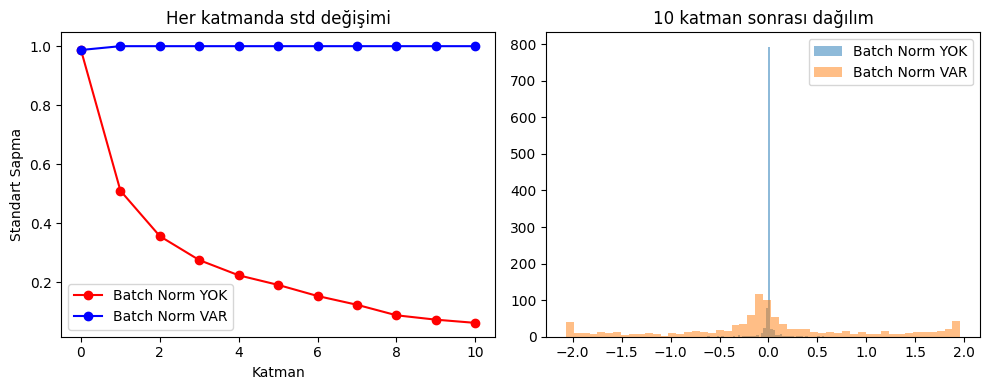

Batch Norm YOK → std: 0.0623
Batch Norm VAR → std: 1.0000


In [6]:
# ══════════════════════════════════════════════════════
# BATCH NORM İLE vs BATCH NORM OLMADAN KARŞILAŞTIRMA
# ══════════════════════════════════════════════════════
#
# Az önce 10 katman sonra std: 0.062 olmuştu
# Şimdi her katmandan sonra Batch Norm ekleyelim
# ══════════════════════════════════════════════════════

np.random.seed(0)

# BATCH NORM OLMADAN
x_no_bn = np.random.randn(1000)
stds_no_bn = [x_no_bn.std()]

for i in range(10):
    W = np.random.randn(*x_no_bn.shape) * 1.0
    x_no_bn = np.tanh(W * x_no_bn)
    stds_no_bn.append(x_no_bn.std())

# BATCH NORM İLE
np.random.seed(0)
x_bn = np.random.randn(1000)
stds_bn = [x_bn.std()]

for i in range(10):
    W = np.random.randn(*x_bn.shape) * 1.0
    x_bn = np.tanh(W * x_bn)

    # Her katmandan sonra normalize et
    mu  = x_bn.mean()
    std = x_bn.std()
    x_bn = (x_bn - mu) / (std + 1e-8)
    stds_bn.append(x_bn.std())

# Grafik
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(stds_no_bn, 'r-o', label='Batch Norm YOK')
plt.plot(stds_bn, 'b-o', label='Batch Norm VAR')
plt.xlabel("Katman")
plt.ylabel("Standart Sapma")
plt.title("Her katmanda std değişimi")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(x_no_bn, bins=50, alpha=0.5, label='Batch Norm YOK')
plt.hist(x_bn, bins=50, alpha=0.5, label='Batch Norm VAR')
plt.title("10 katman sonrası dağılım")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Batch Norm YOK → std: {x_no_bn.std():.4f}")
print(f"Batch Norm VAR → std: {x_bn.std():.4f}")

In [7]:
# ══════════════════════════════════════════════════════
# BATCH NORM BACKWARD PASS
# ══════════════════════════════════════════════════════
#
# Forward:  x → normalize → gamma*x_norm + beta → out
# Backward: grad_out → grad_gamma, grad_beta, grad_x
#
# grad_beta  = toplam(grad_out)
# grad_gamma = toplam(grad_out * x_norm)
# grad_x     = biraz karmaşık (zincir kuralı)
# ══════════════════════════════════════════════════════

def batch_norm_backward(grad_out, cache):
    x, mu, var, x_norm, gamma, beta, eps = cache
    N = x.shape[0]

    # gamma ve beta gradienti — kolay!
    grad_beta  = np.sum(grad_out, axis=0)
    grad_gamma = np.sum(grad_out * x_norm, axis=0)

    # x gradienti — zincir kuralı
    grad_x_norm = grad_out * gamma
    grad_var    = np.sum(grad_x_norm * (x - mu) * -0.5 * (var + eps)**(-1.5), axis=0)
    grad_mu     = np.sum(grad_x_norm * -1 / np.sqrt(var + eps), axis=0)
    grad_x      = (grad_x_norm / np.sqrt(var + eps) +
                   grad_var * 2 * (x - mu) / N +
                   grad_mu / N)

    return grad_x, grad_gamma, grad_beta

# Test edelim
np.random.seed(0)
x     = np.random.randn(100, 4) * 5 + 10
gamma = np.ones(4)
beta  = np.zeros(4)

out, cache = batch_norm_forward(x, gamma, beta)

# Üstten gelen gradient (rastgele)
grad_out = np.random.randn(*out.shape)

grad_x, grad_gamma, grad_beta = batch_norm_backward(grad_out, cache)

print("grad_x shape:    ", grad_x.shape)     # x ile aynı olmalı
print("grad_gamma shape:", grad_gamma.shape)  # gamma ile aynı
print("grad_beta shape: ", grad_beta.shape)   # beta ile aynı
print("\nBackward pass çalışıyor!")

Ortalama: [10.11841092  9.44105219  9.16140901]
Varyans: [29.29472931 23.64017255 19.82587501]
Normalize sonrası → ortalama: -0.000, std: 1.000
Final çıktı → ortalama: -0.000, std: 1.000
grad_x shape:     (100, 4)
grad_gamma shape: (4,)
grad_beta shape:  (4,)

Backward pass çalışıyor!


Ortalama: [ 0.01233598 -0.05568665 -0.05255466]
Varyans: [0.17830398 0.1172079  0.09678459]
Normalize sonrası → ortalama: 0.000, std: 1.000
Final çıktı → ortalama: 0.000, std: 1.000
Ortalama: [ 0.01236647 -0.05685583 -0.05217887]
Varyans: [0.17828295 0.11632311 0.0971588 ]
Normalize sonrası → ortalama: 0.000, std: 1.000
Final çıktı → ortalama: -0.000, std: 1.000
Ortalama: [ 0.01238462 -0.05780138 -0.05181686]
Varyans: [0.17826539 0.11536121 0.09750886]
Normalize sonrası → ortalama: -0.000, std: 1.000
Final çıktı → ortalama: -0.001, std: 0.999
Ortalama: [ 0.01239418 -0.05870961 -0.0515001 ]
Varyans: [0.1782509  0.11439278 0.09777934]
Normalize sonrası → ortalama: 0.000, std: 1.000
Final çıktı → ortalama: -0.001, std: 0.999
Ortalama: [ 0.01239597 -0.0595764  -0.05119452]
Varyans: [0.17823893 0.11341742 0.098039  ]
Normalize sonrası → ortalama: 0.000, std: 1.000
Final çıktı → ortalama: -0.001, std: 0.999
Ortalama: [ 0.01238687 -0.06034976 -0.05084085]
Varyans: [0.17822877 0.11246492 0.098

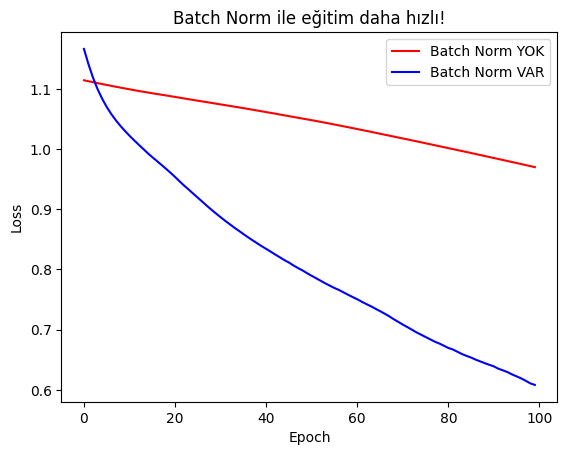

100 epoch sonunda:
Batch Norm YOK → loss: 0.9699
Batch Norm VAR → loss: 0.6082


In [8]:
# ══════════════════════════════════════════════════════
# EĞİTİMDE BATCH NORM ETKİSİ
# ══════════════════════════════════════════════════════
#
# Batch Norm olmadan vs Batch Norm ile eğitim
# Loss'un nasıl değiştiğini karşılaştıralım
#
# Batch Norm'un eğitimdeki yeri:
#   x → FC katman → Batch Norm → ReLU → sonraki katman
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Basit veri
X = np.random.randn(100, 10)   # 100 görüntü, 10 piksel
y = np.random.randint(0, 3, 100)  # 3 sınıf

def softmax_loss(skorlar, y):
    N = skorlar.shape[0]
    e_s = np.exp(skorlar - np.max(skorlar, axis=1, keepdims=True))
    probs = e_s / np.sum(e_s, axis=1, keepdims=True)
    loss = -np.mean(np.log(probs[np.arange(N), y]))
    grad = probs.copy()
    grad[np.arange(N), y] -= 1
    grad /= N
    return loss, grad

# BATCH NORM OLMADAN
W1 = np.random.randn(10, 20) * 0.1
W2 = np.random.randn(20, 3) * 0.1
losses_no_bn = []

for epoch in range(100):
    h = np.maximum(0, X @ W1)
    skorlar = h @ W2
    loss, grad_s = softmax_loss(skorlar, y)
    losses_no_bn.append(loss)
    grad_W2 = h.T @ grad_s
    grad_h  = grad_s @ W2.T * (X @ W1 > 0)
    grad_W1 = X.T @ grad_h
    W1 -= 0.1 * grad_W1
    W2 -= 0.1 * grad_W2

# BATCH NORM İLE
np.random.seed(0)
W1 = np.random.randn(10, 20) * 0.1
W2 = np.random.randn(20, 3) * 0.1
gamma = np.ones(20)
beta  = np.zeros(20)
losses_bn = []

for epoch in range(100):
    # Forward
    h_raw = X @ W1
    out, cache = batch_norm_forward(h_raw, gamma, beta)
    h = np.maximum(0, out)
    skorlar = h @ W2

    loss, grad_s = softmax_loss(skorlar, y)
    losses_bn.append(loss)

    # Backward
    grad_W2 = h.T @ grad_s
    grad_h  = grad_s @ W2.T * (out > 0)
    grad_bn, grad_gamma, grad_beta = batch_norm_backward(grad_h, cache)
    grad_W1 = X.T @ grad_bn

    W1 -= 0.1 * grad_W1
    W2 -= 0.1 * grad_W2
    gamma -= 0.1 * grad_gamma
    beta  -= 0.1 * grad_beta

# Grafik
plt.plot(losses_no_bn, 'r-', label='Batch Norm YOK')
plt.plot(losses_bn, 'b-', label='Batch Norm VAR')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Batch Norm ile eğitim daha hızlı!")
plt.legend()
plt.show()

print(f"100 epoch sonunda:")
print(f"Batch Norm YOK → loss: {losses_no_bn[-1]:.4f}")
print(f"Batch Norm VAR → loss: {losses_bn[-1]:.4f}")

In [9]:
# ══════════════════════════════════════════════════════
# BATCH NORMALIZATION ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║           BATCH NORMALIZATION ÖZET               ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  Problem:                                        ║")
print("║    Derin ağlarda değerler kayar                  ║")
print("║    Gradient sıfıra yaklaşır (vanishing)          ║")
print("║    Eğitim yavaş ve kararsız                      ║")
print("║                                                  ║")
print("║  Çözüm — Batch Norm:                             ║")
print("║    1. Ortalamayı çıkar  → ortalama = 0           ║")
print("║    2. Std'ye böl        → std = 1                ║")
print("║    3. Gamma, beta ile ölçekle (öğrenilir)        ║")
print("║                                                  ║")
print("║  Sonuç:                                          ║")
print("║    Daha hızlı eğitim                             ║")
print("║    Daha yüksek learning rate kullanılabilir      ║")
print("║    Daha kararlı gradient akışı                   ║")
print("║                                                  ║")
print("║  Kullanım yeri:                                  ║")
print("║    x → FC → Batch Norm → ReLU → sonraki katman   ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║           BATCH NORMALIZATION ÖZET               ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  Problem:                                        ║
║    Derin ağlarda değerler kayar                  ║
║    Gradient sıfıra yaklaşır (vanishing)          ║
║    Eğitim yavaş ve kararsız                      ║
║                                                  ║
║  Çözüm — Batch Norm:                             ║
║    1. Ortalamayı çıkar  → ortalama = 0           ║
║    2. Std'ye böl        → std = 1                ║
║    3. Gamma, beta ile ölçekle (öğrenilir)        ║
║                                                  ║
║  Sonuç:                                          ║
║    Daha hızlı eğitim                             ║
║    Daha yüksek learning rate kullanılabilir      ║
║    Daha kararlı gradient akışı                   ║
║                                             